<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/kmeans_clustering_analysis/lab_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In this section, I import all the necessary libraries and functions for performing clustering analysis on the Wine dataset using the K-Means algorithm and evaluating it with silhouette metrics.

In [3]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In this step, I load the Wine dataset from Scikit-learn and convert it into a pandas DataFrame for easier exploration and analysis.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(df.drop(columns=['alcohol']))
df['Cluster_KMeans'] = y_kmeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(df.drop(columns=['alcohol']))
df['Cluster_KMeans'] = y_kmeans

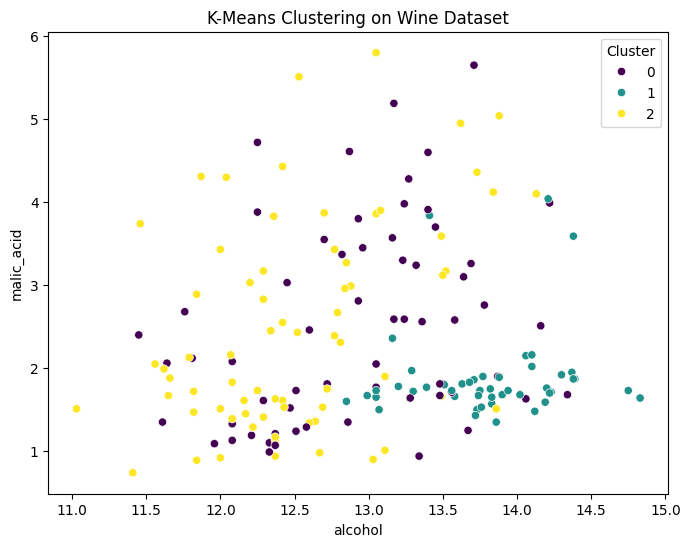

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df['Cluster_KMeans'],
palette='viridis')
plt.title("K-Means Clustering on Wine Dataset")

plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend(title='Cluster')
plt.show()

This code visualizes how the K-Means algorithm divided the Wine dataset into clusters, using the first two features as axes.
Adding labels and a legend makes the plot easier to interpret, especially for presenting results.

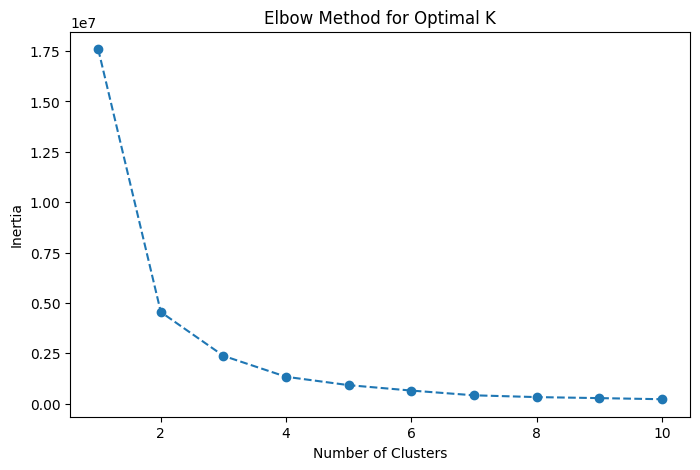

In [6]:
inertia = []
k_values = range(1, 11)
for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(df.drop(columns=['malic_acid', 'Cluster_KMeans']))
  inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

This section uses the Elbow Method to determine the optimal number of clusters (k) for K-Means clustering on the Wine dataset.
It measures how the inertia (the sum of squared distances from each sample to its nearest cluster center) changes as the number of clusters increases.

Average Silhouette Score: 0.57


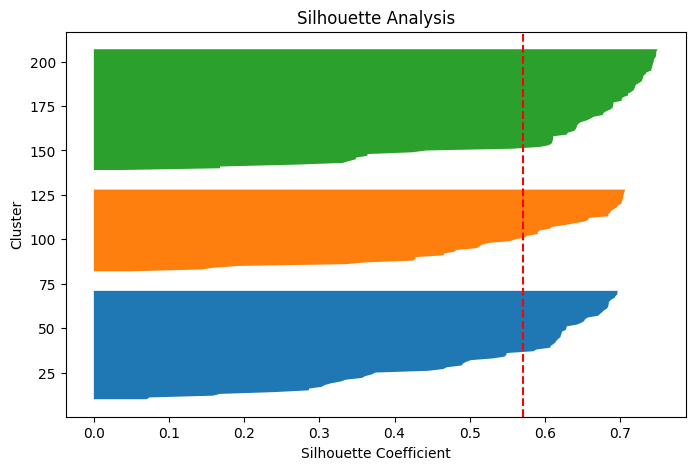

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df.drop(columns=['alcohol',
'Cluster_KMeans']))
silhouette_avg = silhouette_score(df.drop(columns=['alcohol',
'Cluster_KMeans']), labels)
print(f"Average Silhouette Score: {silhouette_avg:.2f}")
silhouette_vals = silhouette_samples(df.drop(columns=['alcohol',
'Cluster_KMeans']), labels)
plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(3):
  ith_silhouette_vals = silhouette_vals[labels == i]
  ith_silhouette_vals.sort()
  y_upper = y_lower + len(ith_silhouette_vals)
  plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette_vals)
  y_lower = y_upper + 10
plt.axvline(x=silhouette_avg, linestyle='--', color='red')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.title('Silhouette Analysis')
plt.show()

The Silhouette Method measures how well data points fit within their assigned clusters compared to neighboring clusters.
It provides both a numerical score (average silhouette) and a visual plot that helps assess:

*   The cohesion of points within each cluster.
*   The separation between different clusters.

Silhouette scores range from –1 to 1:

*   +1 → sample is well matched to its cluster and far from others.
*   0 → sample is on or near the decision boundary between clusters.
*   –1 → sample may be assigned to the wrong cluster.